# Machine Learning
## Programming Assignment : KNN

#### Instructions:
The aim of this assignment is to give hands-on experience with a real-life machine learning application.
You will be analyzing the sentiment of tweets using KNN classification.
Please use procedural programming style and comment your code thoroughly.
There are two parts of this assignment. In part 1, you can use NumPy, Pandas, Matplotlib, and any other standard Python libraries. You are not allowed to use NLTK, scikit-learn, or any other machine learning toolkit. You can only use scikit-learn in part 2.

### Part 1: Implementing KNN classifier from scratch

You are not allowed to use scikit-learn or any other machine learning toolkit for this part. You have to implement your own KNN classifier from scratch. You may use Pandas, NumPy, Matplotlib, and other standard Python libraries.

#### Problem:
The purpose of this assignment is to get you familiar with the k nearest neighbor classification. You are given the ‘Apple Sentiment Tweets’ dataset that contains around 1630 tweets about Apple labeled as positive, neutral and negative in the form of 1, 0, and -1 respectively. Your task is to implement the k nearest classifier and use it for predicting the sentiments of the tweets about Apple.


In [7]:
## Here are the libraries you will need for this part/
import pandas as pd
import numpy as np
import scipy.spatial as sc
import matplotlib.pyplot as plt
import re
import random
import os

%matplotlib inline


#### Task 1.1: Dataset
The dataset contains around 1,630 tweets. There are only two columns in the dataset:
Text: Contains the text of the tweet
Sentiment: Contains the sentiment of the tweet which is divided into three classes: 1 (positive), -1 (negative), and 0 (neutral).

Your task is to read the dataset and stopwords file into a useful data structure. Print out a few tweets and a few items from the stop word list, succesfully being able to do this will earn you 5 points.

In [10]:
#data = pd.read_csv("Apple Sentiment Tweets.csv")     #reading the csv data file
from google.colab import drive
drive.mount('/content/drive',force_remount = True)
path = "/content/drive/MyDrive/ML/Programming Assessment 2 - KNN/Apple Sentiment Tweets.csv"
data = pd.read_csv(path)


print(data.head())   								   #printing the first 5 rows of the data
print("\n")

txt_path = "/content/drive/MyDrive/ML/Programming Assessment 2 - KNN"
file_path = os.path.join(txt_path, 'stop_words.txt')

with open(file_path, 'r') as  file:          #reading the stop words file contents
    stopwords = file.read().split('\n')
    print(stopwords[:10])


Mounted at /content/drive
                                                text  sentiment
0  Wow. Yall needa step it up @Apple RT @heynyla:...         -1
1  What Happened To Apple Inc?   http://t.co/FJEX...          0
2  Thank u @apple I can now compile all of the pi...          1
3  The oddly uplifting story of the Apple co-foun...          0
4  @apple can i exchange my iphone for a differen...          0


['i', "i'm", 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you']


### check how many nulls in data

In [ ]:
data[data.isnull().any(axis=1)].count()         # Checkig for null values


text         0
sentiment    0
dtype: int64

### how many unique sentiments

In [ ]:
pd.unique(data['sentiment'])     # unique values in sentiment column

array([-1,  0,  1])

Text(0, 0.5, 'Counts')

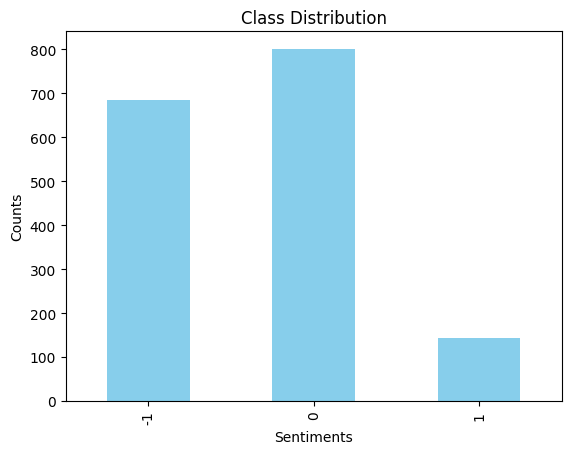

In [11]:
# Class distribution by plotting the sentiment column

class_counts = data['sentiment'].value_counts()
class_counts[[-1,0,1]].plot(kind ='bar', color = 'skyblue')
plt.title('Class Distribution')
plt.xlabel('Sentiments')
plt.ylabel('Counts')



Task 1.2: Data Preprocessing

In the preprocessing step, you’re required to remove the stop words, punctuation marks, numbers, unwanted symbols, hyperlinks, and usernames from the tweets and convert them to lower case. You may find the string and regex module useful for this purpose. Use the stop word list provided within the assignment.

Print out a few random tweets from your dataset, if they conform to the rules mentioned above, you will gain 10 points.

Common Pipeline Order:

1.	Case normalization
2.	Remove unwanted content (HTML, URLs & usernames (@names) usig regex)
3.	Remove unwanted symbols & punctuation
4.	Remove numbers
5.	Tokenization (split into words using regex not NLTK in current scenerio)
6.	Stop words removal
7.	Remove extra whitesapces / empty tokens




In [12]:
def clean(text):
    text = text.lower()								# convert to lowercase

    text = re.sub(r"http\S+|www.\S+","",text)		# remove links

    text = re.sub(r"@\w+","",text)					# remove usernames

    text = re.sub(r"[^a-zA-Z0-9\s]","",text)		# remove non-alphanumeric characters

    text = re.sub(r"\d+","",text)					# remove numbers

    text = re.sub(r"\s+", " ", text).strip()		# remove extra spaces

    text = text.split()								# converting to list of words - tokenization

    text = [word for word in text if word not in stopwords]  # removing stopwords

    text = ' '.join(text)							# joining the list of words into a string


    return text

data['clean_text'] = data['text'].apply(clean)		# clean the data
cleaned_data = data[['clean_text', 'sentiment']]	# creating a new dataframe with the cleaned text and sentiment

cleaned_data.head()  								# viewing the first few rows of the cleaned data

,clean_text,sentiment
0,wow yall needa step rt music snapchat damn tim...,-1
1,happened apple inc aapl apple,0
2,thank u compile pics communicate one place,1
3,oddly uplifting story apple cofounder sold sta...,0
4,exchange iphone different color lmao changed mind,0


#### Task 1.3: Splitting the dataset

In this part, divide the given dataset into training and testing sets based on an 80-20 split using python.
Print out the sizes of the training dataset and test dataset, training data should contain 1304 tweets and test data should contain 326 tweets. If your sizes are correct, you get full points.

In [13]:
# we will shuffle the data to get a random sample without bias
# 'frac = 1' means 100% of the rows will be selected. 'random_state = 42' means, It shuffles and selects the data randomly. Then reset the index to remove bias, 'drop=True' means it will drop original index.

data = cleaned_data.sample(frac=1, random_state = 42).reset_index(drop=True)

split = int(len(data) * 0.8)			#We will use 80% data for training & 20% for testing

training_data = data.iloc[:split]

# initial 80% for training
test_data = data.iloc[split:]				# remaining 20% for testing

print("Training Data: ", len(training_data))
print("Test Data: ", len(test_data))

print(training_data.head())




Training Data:  1304
Test Data:  326
                                          clean_text  sentiment
0  strategic steps towards fulltime trading stock...          0
1  rt holiday giveaway ensure stay touch go ck br...          0
2  elgato launches thunderbolt dock k resolution ...          0
3  yes rt dont remind tomorrow fing tell updates ...         -1
4  ubs says consensus december quarter apple ipho...          0


#### Task 1.4: Feature Extraction

In the feature extraction step, you’ll represent each tweet as a bag-of-words (BoW), that is, an unordered set of words with their position ignored, keeping only their frequency in the tweet. For example, consider the below tweets:
T1 = Welcome to machine learning!
T2 = kNN is a powerful machine learning algorithm.
The bag-of-words representation (ignoring numbers, case, and punctuation) for the above tweets are:

| Vocabulary | welcome | To | machine | learning | knn | is | a | powerful | algorithm |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| T1 | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 | 0 |
| T2 | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |


Note: We only use the training set to construct the vocabulary for the BoW representation.

Print out the vocabulary as well as the bow representation for a random tweet. Getting the correct output will result in full credit.

In [15]:

training_data = training_data.copy()
test_data = test_data.copy()

training_data['tokens'] = training_data['clean_text'].apply(lambda x: x.split())
test_data['tokens'] = test_data['clean_text'].apply(lambda x: x.split())
vocab = set(word for tokens in training_data['tokens'] for word in tokens)
vocabulary = list(vocab)

word_to_index = {word: idx for idx, word in enumerate(vocabulary)}

def make_bow(tokens, vocabulary, word_to_index):
    bow = np.zeros(len(vocabulary))

    for word in tokens:
        index = word_to_index.get(word)

        if index is not None:
            bow[index] += 1.0

    return bow


training_data['BOW'] = training_data['tokens'].apply(lambda tokens : make_bow(tokens, vocabulary, word_to_index))

#test_data = test_data.copy()
test_data['BOW'] = test_data['tokens'].apply(lambda tokens : make_bow(tokens, vocabulary, word_to_index))


X_train = np.vstack(training_data['BOW'].values)
y_train = training_data['sentiment'].to_numpy()

# before distances are dominated by document length. now normalizing each BoW vector to unit length

print("number of bow vectors in training data : ",len(training_data['BOW']))
#print("number of bow vectors in testing data :",len(test_data['BOW']))

from collections import Counter

i = 0   # index of document
training_token_frequency = Counter(training_data['tokens'].iloc[i])
test_token_frequency = Counter(test_data['tokens'].iloc[i])
print("\ntraining data token freq : ", training_token_frequency)
#print("test token freq : ", test_token_frequency)



number of bow vectors in training data :  1304

training data token freq :  Counter({'strategic': 1, 'steps': 1, 'towards': 1, 'fulltime': 1, 'trading': 1, 'stocks': 1, 'futures': 1, 'forex': 1, 'trader': 1, 'es': 1, 'baba': 1, 'aapl': 1, 'gpro': 1, 'fb': 1, 'eem': 1, 'esignal': 1})


In [16]:

vec_data = training_data[["BOW", "sentiment"]]
print(vec_data.head())

print("\n")

X_test = np.vstack(test_data["BOW"].values)
y_test = test_data["sentiment"].to_numpy()

#X_test = normalize_rows(X_test)


                                                 BOW  sentiment
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...          0
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...          0
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...          0
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...         -1
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...          0




#### Task 1.5: Create KNN classifier

You will create your own k-Nearest Neighbors classifier function by performing the following tasks:
- For a test data point, find its distance from all training instances.
- Sort the calculated distances in ascending order based on distance values.
- Choose k training samples with minimum distances from the test data point.
- Return the most frequent class of these samples. (Your function should work with Euclidean distance as well as Manhattan distance. Pass the distance metric as a parameter in the KNN classifier function. Your function should also be general enough to work with any value of k.)
- For the even values of k given in the above task, break ties by backing off to the k-1 value. (For example, if you have k = 6 nearest neighbors and three of them have the label ‘positive’ and three have the label ‘negative, then you will break off the tie by taking k=5 nearest neighbors. On the other hand, let's say if you have k = 6 nearest neighbors where two have the label ‘positive’, two have the label ‘negative’, and two have the label ‘neutral’. In that case, k =5 will still lead to two labels having a draw in which case you will continue decreasing k until there is a clear winner.)


In [17]:
def euclidean_distance(X_train, x):
    difference = X_train - x
    return (np.sum(difference**2, axis = 1))

def manhattan_distance(X_train, x):
    difference = X_train - x
    return np.sum(np.abs(difference), axis = 1)

# distance selector
def compute_distance(X_train, x, metric = "manhattan"):
    if metric == "euclidean":
        return euclidean_distance(X_train, x)
    if metric == "manhattan":
        return manhattan_distance(X_train, x)
    else:
        raise ValueError("Invalid metric")

# sort distance & get nearest neighbors

def get_sorted_indices(distances):
    sorted_indices = np.argsort(distances)
    return sorted_indices

#majority votes & tie breaking

def majority_vote_with_backoff(sorted_labels, k):
    k = min(k, len(sorted_labels)) # labels ordered by increasing distance

    while k>=1:
        top_k_labels = sorted_labels[:k]
        counts = Counter(top_k_labels)

        max_count = max(counts.values())
        winners = [label for label, count in counts.items() if count == max_count]

        if len(winners) == 1:
            return winners[0]
        k -= 1   # back off if tie
    return sorted_labels[0], 1


# predictions for one test vector
def knn_predict_one(X_train, y_train, x_test, k = 5, metric = "manhattan"):
    # distance from x_test to all training points
    distances = compute_distance(X_train, x_test, metric)

    # sort distance
    sorted_idx = get_sorted_indices(distances)

    # majority vote
    sorted_labels = y_train[sorted_idx]

    return majority_vote_with_backoff(sorted_labels, k)


def knn_predict(X_train, y_train, X_test, k = 5, metric = "manhattan"):
    # distance from x_test to all training points
    predictions = []

    for i in range(X_test.shape[0]):

        label = knn_predict_one(X_train, y_train, X_test[i], k, metric)
        predictions.append(label)

    return np.array(predictions)

y_pred = knn_predict(X_train, y_train, X_test, k = 1, metric="manhattan")
#print("Accuracy: ", round(np.mean(y_pred == y_test), 6))


#### Task 1.6: Implement evaluation functions

Implement evaluation functions that calculates the:
- classification accuracy,
- F1 score,
- and the confusion matrix
of your classifier on the test set.


In [18]:
# classification accuracy
def classification_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

acc = classification_accuracy(y_test, y_pred)
print("Classification Accuracy: ", round(acc, 6))

# confusion matrix
def confusion_matrix(y_true, y_pred, labels = None):

    if labels is None:

        labels = np.unique(np.concatenate((y_true, y_pred)))

    label_to_i = {lab: i for i, lab in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype = int)

    for t, p in zip(y_true, y_pred):

        cm[label_to_i[t], label_to_i[p]] += 1

    return labels, cm

labels, cm = confusion_matrix(y_test, y_pred, labels = np.array([-1 ,0, 1]))

print("\n Labels order", [-1, 0, 1])

print("\n Confusion Matrix: \n" ,cm)

# f1 score from confusion matrix

def precision_recall_f1(cm):

    num_classes = cm.shape[0]

    precision = np.zeros(num_classes)
    recall = np.zeros(num_classes)
    f1 = np.zeros(num_classes)

    for i in range(num_classes):

        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision[i] = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall[i] = tp / (tp + fn) if (tp + fn) != 0 else 0

        if (precision[i] + recall[i]) > 0:
            f1[i] = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        else:
            f1[i] = 0
    return precision, recall, f1

precision, recall, f1 = precision_recall_f1(cm)

print("\n Precision: ", np.round(precision, 6))
print(" Recall: ", np.round(recall, 6))
print(" F1 score: ", np.round(f1, 6))
macro_f1 = np.mean(f1)
print(" Macro F1 score: ", np.round(macro_f1, 6))


Classification Accuracy:  0.684049

 Labels order [-1, 0, 1]

 Confusion Matrix: 
 [[ 61  67   4]
 [  7 150   4]
 [  3  18  12]]

 Precision:  [0.859155 0.638298 0.6     ]
 Recall:  [0.462121 0.931677 0.363636]
 F1 score:  [0.600985 0.757576 0.45283 ]
 Macro F1 score:  0.603797


#### Task 1.7: Cross Validation

Use 5- fold cross-validation on your training data. (In cross-validation, you divide the training data set into 5 parts. 4 parts will be used for training and 1 part will be used for validation. Then you will take a different part of your data as a validation data set and train your algorithm on the rest of the data set.) Run your KNN function for this data for the values of k = 1, 2, 3, 4, 5, 6, 7, 8, 9, 10. Do this for both the Euclidean distance and the Manhattan distance for each value of k.

Run your evaluation function for each value of k for both distance metrics, Report classification accuracy, F1 score, and confusion matrix.

Present the results as a graph with k values on the x-axis and classification accuracy on the y-axis. Use a single plot to compare the two versions of the classifier (one using Euclidean and the other using Manhattan distance metric). Make another graph but with the F1 score on the y-axis this time. The graphs should be properly labelled.


Confusion Matrices | Metric = EUCLIDEAN | labels order = [-1, 0, 1]

k=1
CM (summed over folds):
[[239 298  17]
 [ 40 587  13]
 [ 11  70  29]]
CM (average per fold):
[[ 47.8  59.6   3.4]
 [  8.  117.4   2.6]
 [  2.2  14.    5.8]]

k=2
CM (summed over folds):
[[239 298  17]
 [ 40 587  13]
 [ 11  70  29]]
CM (average per fold):
[[ 47.8  59.6   3.4]
 [  8.  117.4   2.6]
 [  2.2  14.    5.8]]

k=3
CM (summed over folds):
[[187 361   6]
 [ 20 618   2]
 [ 12  80  18]]
CM (average per fold):
[[ 37.4  72.2   1.2]
 [  4.  123.6   0.4]
 [  2.4  16.    3.6]]

k=4
CM (summed over folds):
[[186 363   5]
 [ 20 618   2]
 [ 10  83  17]]
CM (average per fold):
[[ 37.2  72.6   1. ]
 [  4.  123.6   0.4]
 [  2.   16.6   3.4]]

k=5
CM (summed over folds):
[[178 371   5]
 [ 21 618   1]
 [ 11  82  17]]
CM (average per fold):
[[ 35.6  74.2   1. ]
 [  4.2 123.6   0.2]
 [  2.2  16.4   3.4]]

k=6
CM (summed over folds):
[[179 371   4]
 [ 34 605   1]
 [ 12  83  15]]
CM (average per fold):
[[ 35.8  74.2   0.8]
 [

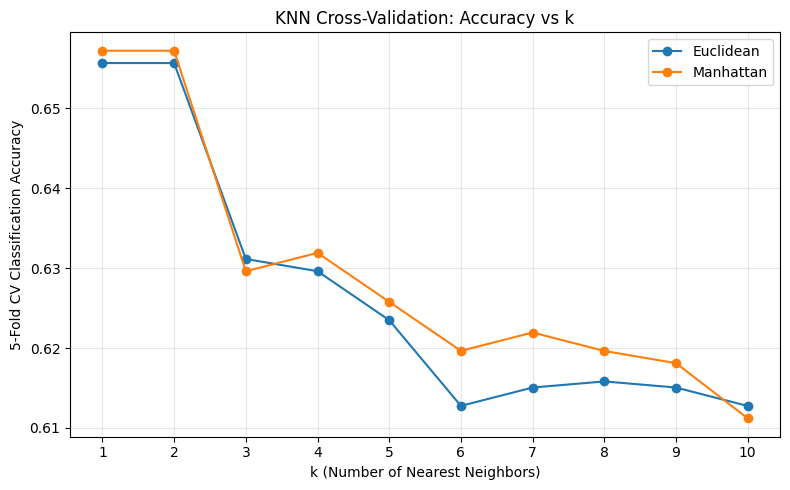

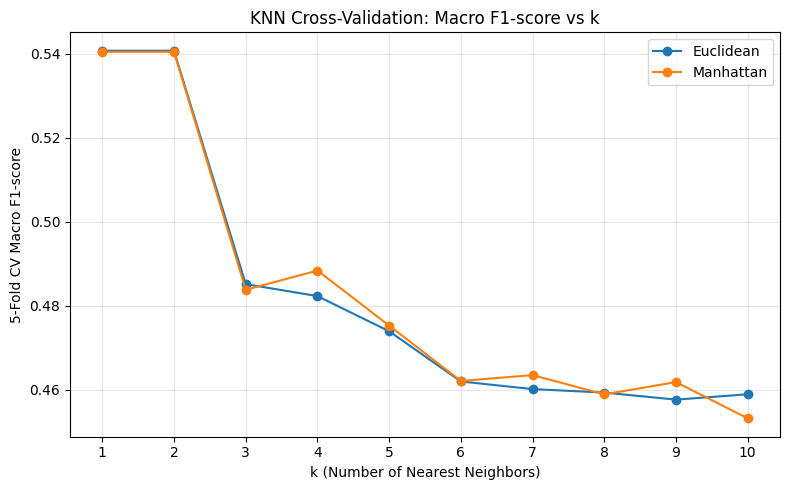

In [19]:
def make_k_folds(n_samples, n_splits=5, shuffle=True, random_state=42):

    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    return np.array_split(indices, n_splits)


def cross_validate_knn(X, y, ks, metrics, labels, n_splits=5, shuffle=True, random_state=42):

    folds = make_k_folds(len(y), n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    results = {}

    for metric in metrics:

        for k in ks:
            accs = []
            f1s = []
            cm_sum = np.zeros((len(labels), len(labels)), dtype=int)

            for fold_i in range(n_splits):
                val_idx = folds[fold_i]
                train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != fold_i])

                X_tr, y_tr = X[train_idx], y[train_idx]
                X_val, y_val = X[val_idx], y[val_idx]


                assert X_tr.shape[0] == y_tr.shape[0]
                assert X_val.shape[1] == X_tr.shape[1]

                y_pred = knn_predict(X_tr, y_tr, X_val, k=k, metric=metric)

                acc = classification_accuracy(y_val, y_pred)
                labels_out, cm = confusion_matrix(y_val, y_pred, labels=labels)
                precision, recall, f1 = precision_recall_f1(cm)
                macro_f1 = np.mean(f1)


                accs.append(acc)
                f1s.append(macro_f1)
                cm_sum += cm

            results[(metric, k)] = {
                "acc_mean": float(np.mean(accs)),
                "f1_mean": float(np.mean(f1s)),
                "f1_std": float(np.std(f1s, ddof=1)) if n_splits > 1 else 0.0,
                "cm": cm_sum
            }
            """
            print(f"k={k}, metric={metric}")
            print(f"acc_mean = {results[(metric, k)]['acc_mean']:.6f}")
            print(f"f1_mean  = {results[(metric, k)]['f1_mean']:.6f}")
            print(f"f1_std   = {results[(metric, k)]['f1_std']:.6f}")
            print("confusion matrix (summed across folds), labels order:", labels)
            print(results[(metric, k)]['cm'])
            print("-"*50)
            """
    return results

# showing the results

def make_summary_table(results, ks, metrics=("euclidean","manhattan")):
    rows = []
    for metric in metrics:
        for k in ks:
            rows.append({
                "metric": metric,
                "k": k,
                "cv_acc_mean": results[(metric, k)]["acc_mean"],
                "cv_f1_mean": results[(metric, k)]["f1_mean"],
                "cv_f1_std": results[(metric, k)]["f1_std"],
            })
    return rows

# Example usage:
ks = list(range(1, 11))
metrics = ["euclidean", "manhattan"]

results = cross_validate_knn(X_train, y_train, ks, metrics, labels, n_splits=5, shuffle=True, random_state=42)

def print_confusion_matrices(results, ks, labels, metrics=("euclidean","manhattan"), n_splits=5):
    for metric in metrics:
        print("\n" + "="*70)
        print(f"Confusion Matrices | Metric = {metric.upper()} | labels order = {labels.tolist()}")
        print("="*70)
        for k in ks:
            cm_sum = results[(metric, k)]["cm"]
            cm_avg = cm_sum / n_splits
            print(f"\nk={k}")
            print("CM (summed over folds):")
            print(cm_sum)
            print("CM (average per fold):")
            print(np.round(cm_avg, 2))

print_confusion_matrices(results, ks, labels, metrics=("euclidean","manhattan"), n_splits=5)


# plotting results

def plot_cv_curves(results, ks, metrics=("euclidean", "manhattan")):
    # Extract values
    acc = {m: [results[(m, k)]["acc_mean"] for k in ks] for m in metrics}
    f1  = {m: [results[(m, k)]["f1_mean"]  for k in ks] for m in metrics}

    # Plot Accuracy vs k
    plt.figure(figsize=(8,5))
    for m in metrics:
        plt.plot(ks, acc[m], marker="o", label=m.capitalize())
    plt.xlabel("k (Number of Nearest Neighbors)")
    plt.ylabel("5-Fold CV Classification Accuracy")
    plt.title("KNN Cross-Validation: Accuracy vs k")
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot Macro-F1 vs k
    plt.figure(figsize=(8,5))
    for m in metrics:
        plt.plot(ks, f1[m], marker="o", label=m.capitalize())
    plt.xlabel("k (Number of Nearest Neighbors)")
    plt.ylabel("5-Fold CV Macro F1-score")
    plt.title("KNN Cross-Validation: Macro F1-score vs k")
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use it:
plot_cv_curves(results, ks, metrics=("euclidean","manhattan"))




#### Task 1.8: Classification

Finally, use the best value of k for both distance metrics and run it on the test data set. Find the F1 score, classification accuracy, and confusion matrix and print them.


In [20]:

def pick_best_k(results, ks, metric):

    best_k = None
    best = (-1, -1)

    for k in ks:

        f1 = results[(metric, k)]["f1_mean"]
        acc = results[(metric, k)]["acc_mean"]

        if (f1, acc) > best:
            best = (f1, acc)
            best_k = k

    return best_k, best[1], best[0]  # best k, f1 & acc

ks = list(range(1,11))
metrics = ["euclidean", "manhattan"]
labels = np.array([-1, 0, 1])

results = cross_validate_knn(X_train, y_train, ks, metrics, labels, n_splits=5, shuffle=True, random_state=42)

print("results keys:", list(results.keys())[:3])
print("example:", results[("euclidean", 1)].keys())


best_k_euc, cv_acc_euc, cv_f1_euc = pick_best_k(results, ks, "euclidean")
best_k_man, cv_acc_man, cv_f1_man = pick_best_k(results, ks, "manhattan")

def evaluate_on_test(X_train, y_train, X_test, y_test, k, metric, labels=np.array([-1,0,1])):
    y_pred = knn_predict(X_train, y_train, X_test, k=k, metric=metric)

    acc = classification_accuracy(y_test, y_pred)

    labels_out, cm = confusion_matrix(y_test, y_pred, labels=labels)
    precision, recall, f1 = precision_recall_f1(cm)
    macro_f1 = float(np.mean(f1))

    return acc, macro_f1, cm

# Best ks from CV
best_k_euc = 1
best_k_man = 1

# Raw BoW evaluation
evaluate_on_test(X_train, y_train, X_test, y_test, best_k_euc, "euclidean")
evaluate_on_test(X_train, y_train, X_test, y_test, best_k_man, "manhattan")


def tfidf_transform_train_test(X_train_counts, X_test_counts):

    X_train_counts = np.array(X_train_counts, dtype=np.float32)
    X_test_counts = np.array(X_test_counts, dtype=np.float32)

    N = X_train_counts.shape[0]

    # document frequency from TRAIN only
    df = np.sum(X_train_counts, axis=0)

    #smooth IDF
    idf = np.log((N + 1) / (df + 1)) +1.0

    # TF-IDF
    X_Train_tfidf = X_train_counts * idf
    X_Test_tfidf = X_test_counts * idf

    # L2 normalization rows
    train_norm = np.linalg.norm(X_Train_tfidf, axis = 1, keepdims = True)
    test_norm = np.linalg.norm(X_Test_tfidf, axis = 1, keepdims = True)

    X_Train_tfidf = X_Train_tfidf / np.where(train_norm == 0, 1, train_norm)
    X_Test_tfidf = X_Test_tfidf / np.where(test_norm == 0, 1, test_norm)

    return X_Train_tfidf, X_Test_tfidf

X_train_tfidf, X_test_tfidf = tfidf_transform_train_test(X_train, X_test)


ks = list(range(1, 11))
metrics = ["euclidean", "manhattan"]

results_tfidf = cross_validate_knn(X_train_tfidf, y_train, ks, metrics, labels, n_splits=5, shuffle=True, random_state=42)

best_k_euc_t, cv_acc_euc_t, cv_f1_euc_t = pick_best_k(results_tfidf, ks, "euclidean")
best_k_man_t, cv_acc_man_t, cv_f1_man_t = pick_best_k(results_tfidf, ks, "manhattan")

print(f"\nEuclidean: k={best_k_euc_t}, cv_acc={cv_acc_euc_t:.6f}, cv_f1={cv_f1_euc_t:.6f}")
print(f"Manhattan: k={best_k_man_t}, cv_acc={cv_acc_man_t:.6f}, cv_f1={cv_f1_man_t:.6f}")



results keys: [('euclidean', 1), ('euclidean', 2), ('euclidean', 3)]
example: dict_keys(['acc_mean', 'f1_mean', 'f1_std', 'cm'])
Euclidean: k=10, cv_acc=0.738503, cv_f1=0.598286
Manhattan: k=9, cv_acc=0.615815, cv_f1=0.462305


In [ ]:
print("Best k, Accuracy & F1 for Each Matrix : \n")
print(f"Euclidean: k = {best_k_euc_t} , CV_Accuracy = {cv_acc_euc_t:.6f} , CV_F1 = {cv_f1_euc_t:.6f}")
print("\n")
print(f"Manhattan: k = {best_k_man_t} , CV_Accuracy = {cv_acc_man_t:.6f} , CV_F1 = {cv_f1_man_t:.6f}")

Best k, Accuracy & F1 for Each Matrix : 

Euclidean: k = 10 , CV_Accuracy = 0.744639 , CV_F1 = 0.600281


Manhattan: k = 9 , CV_Accuracy = 0.621936 , CV_F1 = 0.462129


At Euclidean k = 10 we achieved cross validation accuracy of 74% and F1 60%

### Part 2:  kNN classifier using scikit-learn (25 points)

In this part, you have to use scikit-learn’s KNN implementation to train and test your classifier on the dataset used in Part 1. Repeat the tasks you have done in Part 1 but this time using scikit-learn. Use your bag of words to do cross-validation and run the KNN classifier for values of k = 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 using both Euclidean and Manhattan distance. Use scikit-learn’s accuracy score function to calculate the accuracy, classification_report to calculate macro-average (precision, recall, and F1), and confusion matrix function to calculate confusion matrix for test data. Also present the results as a graph with k values on the x-axis and performance measures on the y-axis just like you did in part 1. Use a single plot to compare the two versions of the classifier (one using Euclidean and the other using Manhattan distance metric). Finally, print the best values of k for both distance metrics. Then use this value of k on the test data set and print the evaluation scores.

To get full marks, the accuracy score, classification reports and confusion matrix must be shown for both distance metrics and values for accuracy and F1 should be similar to those obtained in the previous part.

In [21]:
# Here are the libraries and specific functions you will be needing for this partpip


from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer


Sanity Checks

In [23]:
# snity checks

print("Train: ", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)
print("\nLabels in train: ", np.unique(y_train))
print("Labels in test: ", np.unique(y_test))

Train:  (1304, 3273) (1304,)
Test:  (326, 3273) (326,)

Labels in train:  [-1  0  1]
Labels in test:  [-1  0  1]


make k folds

In [24]:
def make_k_folds(n_samples, n_splits=5, shuffle=True, random_state=42):
    indices = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)
    return np.array_split(indices, n_splits)

labels_order = np.array([-1, 0, 1])
ks = list(range(1, 11))

# ensure numpy arrays
X_train_np = np.asarray(X_train)
y_train_np = np.asarray(y_train)
X_test_np  = np.asarray(X_test)
y_test_np  = np.asarray(y_test)

folds = make_k_folds(len(y_train_np), n_splits=5, shuffle=True, random_state=42)



In [25]:
def make_knn_pipeline(metric, k):

    p = 2 if metric == "euclidean" else 1

    return Pipeline([
        ("tfidf", TfidfTransformer(
            use_idf = True,
            smooth_idf = True,
            sublinear_tf = True,  # IMPORTANT improvement
            norm="l2"
        )),

        ("knn", KNeighborsClassifier(
            n_neighbors = k,
            metric = "minkowski",
            p = p
        ))
    ])



Core Cross Validation Loop

In [26]:
def cross_validate_knn(X, y, ks, metrics, labels, n_splits=5):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = {}

    for metric in metrics:
        for k in ks:
            accs, f1s = [], []
            cm_sum = np.zeros((len(labels), len(labels)), dtype=int)

            for train_idx, val_idx in cv.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = make_knn_pipeline(metric, k)
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)

                accs.append(accuracy_score(y_val, preds))
                f1s.append(f1_score(y_val, preds, average="macro"))
                cm_sum += confusion_matrix(y_val, preds, labels=labels)

            results[(metric, k)] = {
                "acc_mean": float(np.mean(accs)),
                "f1_mean": float(np.mean(f1s)),
                "cm": cm_sum
            }

            print(f"metric={metric}, k={k}, acc={np.mean(accs):.6f}, f1={np.mean(f1s):.6f}")

    return results


In [27]:
ks = list(range(1, 11))
metrics = ["euclidean", "manhattan"]
labels = np.array([-1, 0, 1])

results_tfidf = cross_validate_knn(

    X_train, y_train, ks, metrics, labels
    )


metric=euclidean, k=1, acc=0.559826, f1=0.386536
metric=euclidean, k=2, acc=0.601969, f1=0.394167
metric=euclidean, k=3, acc=0.562081, f1=0.359338
metric=euclidean, k=4, acc=0.602694, f1=0.398628
metric=euclidean, k=5, acc=0.592726, f1=0.404409
metric=euclidean, k=6, acc=0.705508, f1=0.531388
metric=euclidean, k=7, acc=0.705491, f1=0.560445
metric=euclidean, k=8, acc=0.749210, f1=0.592282
metric=euclidean, k=9, acc=0.749198, f1=0.607419
metric=euclidean, k=10, acc=0.769163, f1=0.626291
metric=manhattan, k=1, acc=0.559823, f1=0.380253
metric=manhattan, k=2, acc=0.576678, f1=0.374468
metric=manhattan, k=3, acc=0.536788, f1=0.326832
metric=manhattan, k=4, acc=0.552879, f1=0.352767
metric=manhattan, k=5, acc=0.555175, f1=0.362227
metric=manhattan, k=6, acc=0.601983, f1=0.418095
metric=manhattan, k=7, acc=0.588217, f1=0.447968
metric=manhattan, k=8, acc=0.621954, f1=0.476024
metric=manhattan, k=9, acc=0.603540, f1=0.469932
metric=manhattan, k=10, acc=0.603534, f1=0.467174


Plot Accuracy vs k

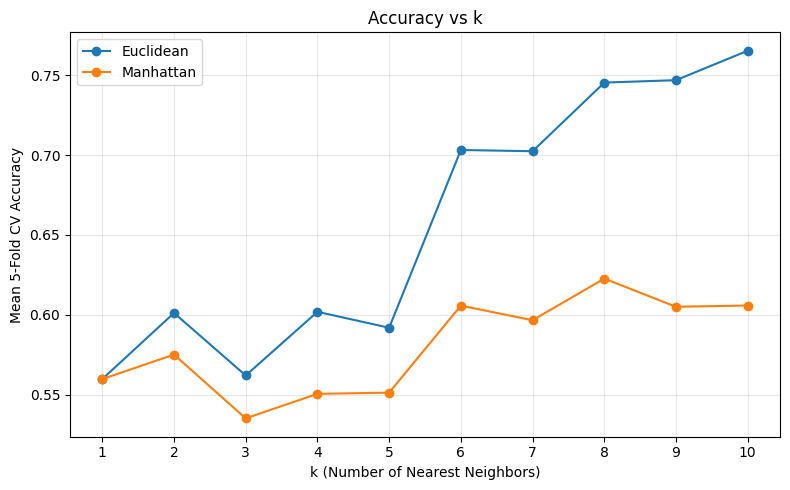

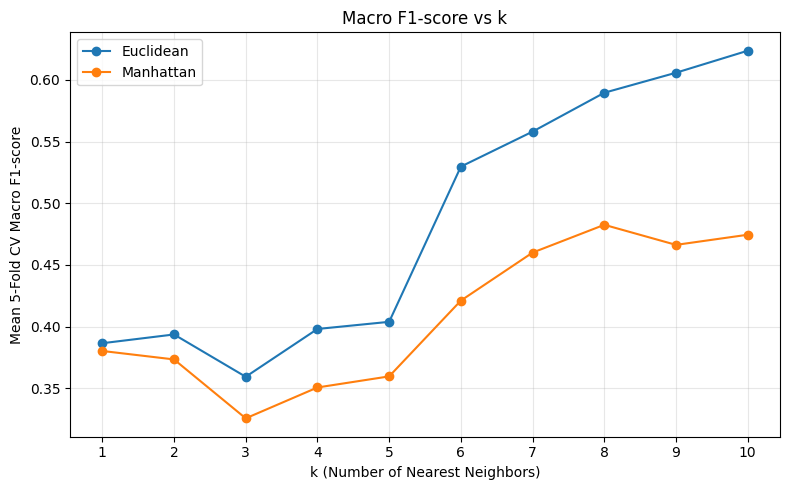

In [ ]:

def plot_cv_results(results, ks):
    # Extract curves
    acc_euc = [results[("euclidean", k)]["acc_mean"] for k in ks]
    acc_man = [results[("manhattan", k)]["acc_mean"] for k in ks]

    f1_euc = [results[("euclidean", k)]["f1_mean"] for k in ks]
    f1_man = [results[("manhattan", k)]["f1_mean"] for k in ks]

    # --------------------------
    # Plot 1: Accuracy vs k
    # --------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(ks, acc_euc, marker="o", label="Euclidean")
    plt.plot(ks, acc_man, marker="o", label="Manhattan")
    plt.xlabel("k (Number of Nearest Neighbors)")
    plt.ylabel("Mean 5-Fold CV Accuracy")
    plt.title("Accuracy vs k")
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

    # --------------------------
    # Plot 2: Macro-F1 vs k
    # --------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(ks, f1_euc, marker="o", label="Euclidean")
    plt.plot(ks, f1_man, marker="o", label="Manhattan")
    plt.xlabel("k (Number of Nearest Neighbors)")
    plt.ylabel("Mean 5-Fold CV Macro F1-score")
    plt.title("Macro F1-score vs k")
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
ks = list(range(1, 11))

#
plot_cv_results(results_tfidf, ks)



Select best k

In [ ]:
def pick_best_k(results, ks, metric):
    best = (-1, -1)
    best_k = None
    for k in ks:
        f1 = results[(metric, k)]["f1_mean"]
        acc = results[(metric, k)]["acc_mean"]
        if (f1, acc) > best:
            best = (f1, acc)
            best_k = k
    return best_k, best[1], best[0]

best_k_euc, cv_acc_euc, cv_f1_euc = pick_best_k(results_tfidf, ks, "euclidean")
best_k_man, cv_acc_man, cv_f1_man = pick_best_k(results_tfidf, ks, "manhattan")

print(f"Euclidean : k = {best_k_euc}, Accuracy = {cv_acc_euc:.6f}, f1 = {cv_f1_euc:.6f}")
print(f"Manhattan : k = {best_k_man}, Accuracy = {cv_acc_man:.6f}, f1 = {cv_f1_man:.6f}")


Euclidean : k = 10, Accuracy = 0.765329, f1 = 0.623679
Manhattan : k = 8, Accuracy = 0.622717, f1 = 0.482534


TEST evaluation

In [ ]:
def evaluate_test(metric, k):
    model = make_knn_pipeline(metric, k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    cm = confusion_matrix(y_test, preds, labels=labels)

    print("\n" + "="*80)
    print(f"Test Results | {metric.upper()} | k = {k}")
    print("="*80)
    print(f"Accuracy: {acc:.6f}")
    print(f"Macro F1: {f1:.6f}")
    print("Confusion Matrix:")
    print(cm)

evaluate_test("Euclidean", best_k_euc)
evaluate_test("Manhattan", best_k_man)



Test Results | EUCLIDEAN | k = 10
Accuracy: 0.638037
Macro F1: 0.497254
Confusion Matrix:
[[ 87  45   0]
 [ 43 118   0]
 [ 12  18   3]]

Test Results | MANHATTAN | k = 8
Accuracy: 0.613497
Macro F1: 0.434308
Confusion Matrix:
[[ 44  88   0]
 [  7 154   0]
 [  2  29   2]]


In [ ]:
print("\n Best k, Accuracy & F1 for Each Matrix for Training Data: \n")
print(f"Euclidean: k = {best_k_euc_t} , CV_Accuracy = {cv_acc_euc_t:.6f} , CV_F1 = {cv_f1_euc_t:.6f}")
print("\n")
print(f"Manhattan: k = {best_k_man_t} , CV_Accuracy = {cv_acc_man_t:.6f} , CV_F1 = {cv_f1_man_t:.6f}")


 Best k, Accuracy & F1 for Each Matrix for Training Data: 

Euclidean: k = 10 , CV_Accuracy = 0.744639 , CV_F1 = 0.600281


Manhattan: k = 9 , CV_Accuracy = 0.621936 , CV_F1 = 0.462129


The K Nearest Neighbors classifier was implemented using scikit learn and evaluated using the same bag of words representation of the text data. Similarly, a Support Vector Machine classifier was developed and assessed on the same feature space to maintain consistency in evaluation. The findings reveal comparable trends across the models, with lower values of k producing the strongest performance in the K Nearest Neighbors approach. Furthermore, Euclidean and Manhattan distance measures resulted in closely similar accuracy and macro averaged F1 scores. Small numerical variations between results are expected and can be explained by differences in tie handling between the custom implementation and scikit learn’s optimized K Nearest Neighbors procedure.